In [1]:

import DeepST
import scanpy as sc
import louvain
import leidenalg
import sklearn
import sknetwork

import os
from DeepST.deepst.DeepST import run
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd


In [2]:
def save_file(adata, results_path):

    # Create a DataFrame for submission
    submission_df = pd.DataFrame({
        'Id': adata.obs_names,  # Assuming the index of adata corresponds to your Spot IDs
        'Label': adata.obs['DeepST_refine_domain']  # Your clustering results
    })

    submission_df.to_csv(results_path, index = False)


(1950, 32285)
Physical distance calculting Done!
The number of nearest tie neighbors in physical distance is: 30.0
Gene correlation calculting Done!
The weight result of image feature is added to adata.obsm['weights_matrix_all'] !


Find adjacent spots of each spot: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████ [ time left: 00:00 ]


Step 1: Augment molecule expression is Done!
12.0000 neighbors per cell on average.
Step 2: Graph computing is Done!
Your task is in full swing, please wait


DeepST trains an initial model: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████ [ time left: 00:00 ]
DeepST trains a final model:   0%|                                                                                                                           [ time left: ? ]/home/ajita/anaconda3/envs/deepst/lib/python3.9/site-packages/torch/nn/functional.py:3369: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(
DeepST trains a final model: |                                                                                                                           [ time left: 00:00 ]


Step 3: DeepST training has been Done!
Current memory usage：4.2738 GB
Total time: 0.53 minutes
Your task has been completed, thank you
Of course, you can also perform downstream analysis on the processed data
Best resolution:  0.7999999999999996


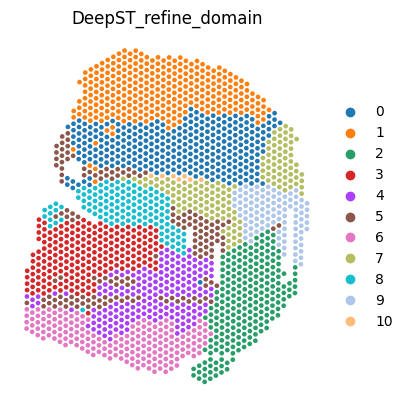

In [3]:

# Number of spatial domains for the MERFISH dataset
n_domains = 11

method_name = "DeepST"

save_path = "/data/Ajita/Spatial/Datasets/Spatial_Domain/Real_datasets/mouse_breast_cancer/final_domain_outputs/"

path = "/data/Ajita/Spatial/Datasets/Spatial_Domain/Real_datasets/mouse_breast_cancer/mouse_breast_cancer.h5ad"

results_path = "/data/Ajita/Spatial/Datasets/Spatial_Domain/Real_datasets/mouse_breast_cancer/final_domain_outputs/" \
+ "/output_" + method_name + ".csv"
adata = sc.read_h5ad(path)

print(adata.shape)

spatial_coordinates = adata.obsm['spatial']
#print(spatial_coordinates)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)  # Log transformation

# Initialize the DeepST run class
deepen = run(
    save_path=save_path,
    task="Identify_Domain",
    pre_epochs=800,  # Number of pre-training epochs
    epochs=1000,  # Number of training epochs
    use_gpu=True  # Set to False if using CPU
)


# Process and augment data
adata = deepen._get_augment(adata, spatial_type="BallTree", use_morphological=False)

# Build graphs
graph_dict = deepen._get_graph(adata.obsm["spatial"], distType="BallTree")

# Enhanced data preprocessing
data = deepen._data_process(adata, pca_n_comps=50)

# Training models
deepst_embed = deepen._fit(data=data, graph_dict=graph_dict)

# DeepST outputs
adata.obsm["DeepST_embed"] = deepst_embed

# Define the number of spatial domains
adata = deepen._get_cluster_data(adata, n_domains=n_domains, priori=True)

# Visualizing spatial localization
sc.pl.spatial(adata, color='DeepST_refine_domain', frameon=False, spot_size=150)
save_file(adata, results_path)
    

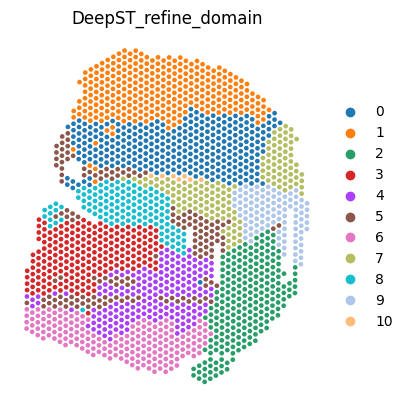

In [4]:
# Visualizing spatial localization
sc.pl.spatial(adata, color='DeepST_refine_domain', frameon=False, spot_size=150)
save_file(adata, results_path)